# 02 - EDA

Exploré distribuciones y relación con el target. La variable más predictiva es categórica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 90

df = pd.read_excel(Path('..') / 'data' / 'raw' / 'smoking_labeled.xlsx')
df.shape

(50000, 27)

## Distribucion del target

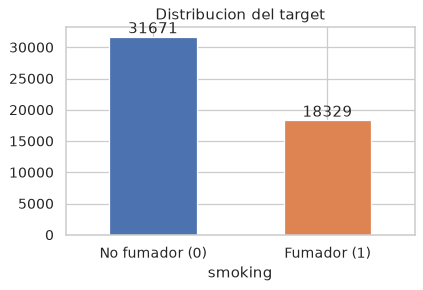

In [2]:
fig, ax = plt.subplots(figsize=(5, 3))
df['smoking'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No fumador (0)', 'Fumador (1)'], rotation=0)
ax.set_title('Distribucion del target')
for p in ax.patches: ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

## Categoricas vs target

La variable mas predictiva es **categorica, no numerica**. Veamos `gender` y `tartar`.

In [3]:
# gender es la que más se nota a simple vista
for c in ['gender', 'tartar', 'dental caries', 'hearing(left)', 'hearing(right)']:
    ct = pd.crosstab(df[c], df['smoking'], normalize='index')
    print(f'\n=== {c} (prop. de fumadores por categoria) ===')
    print(ct.round(3))


=== gender (prop. de fumadores por categoria) ===
smoking      0      1
gender               
F        0.957  0.043
M        0.448  0.552

=== tartar (prop. de fumadores por categoria) ===
smoking      0      1
tartar               
N        0.687  0.313
Y        0.590  0.410

=== dental caries (prop. de fumadores por categoria) ===
smoking            0      1
dental caries              
0              0.659  0.341
1              0.537  0.463

=== hearing(left) (prop. de fumadores por categoria) ===
smoking            0      1
hearing(left)              
0.041667       0.632  0.368
0.083333       0.698  0.302

=== hearing(right) (prop. de fumadores por categoria) ===
smoking             0      1
hearing(right)              
0.041667        0.632  0.368
0.083333        0.685  0.315


> Para `gender` la tasa de fumadores en M es mucho mas alta que en F: esta unica variable tiene mas poder predictivo que cualquier numerica.

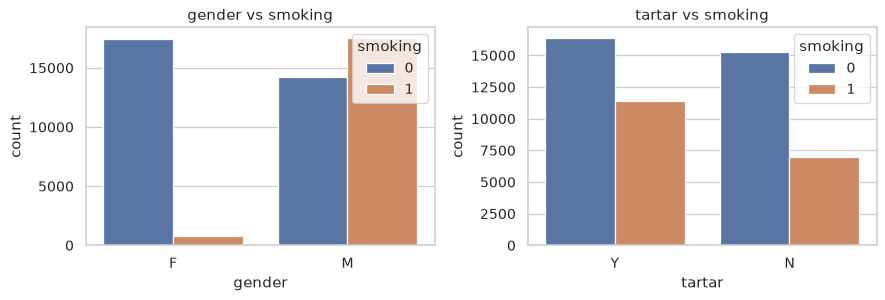

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.countplot(data=df, x='gender', hue='smoking', ax=axes[0])
axes[0].set_title('gender vs smoking')
sns.countplot(data=df, x='tartar', hue='smoking', ax=axes[1])
axes[1].set_title('tartar vs smoking')
plt.tight_layout(); plt.show()

## Numericas: distribuciones por target

Quick view de algunas variables clinicas. `hemoglobin`, `triglyceride`, `Gtp` y `waist(cm)` suelen mostrar diferencia clara entre fumadores y no fumadores.

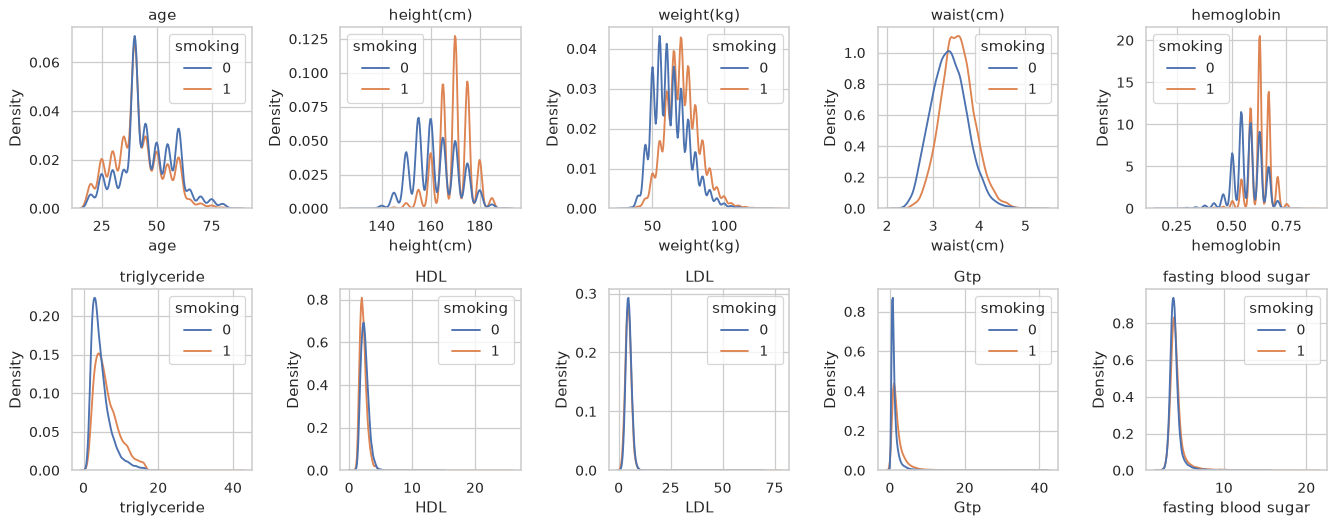

In [5]:
num_focus = ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'hemoglobin',
             'triglyceride', 'HDL', 'LDL', 'Gtp', 'fasting blood sugar']
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, col in zip(axes.flat, num_focus):
    sns.kdeplot(data=df, x=col, hue='smoking', common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

## Boxplots (por si las dudas)

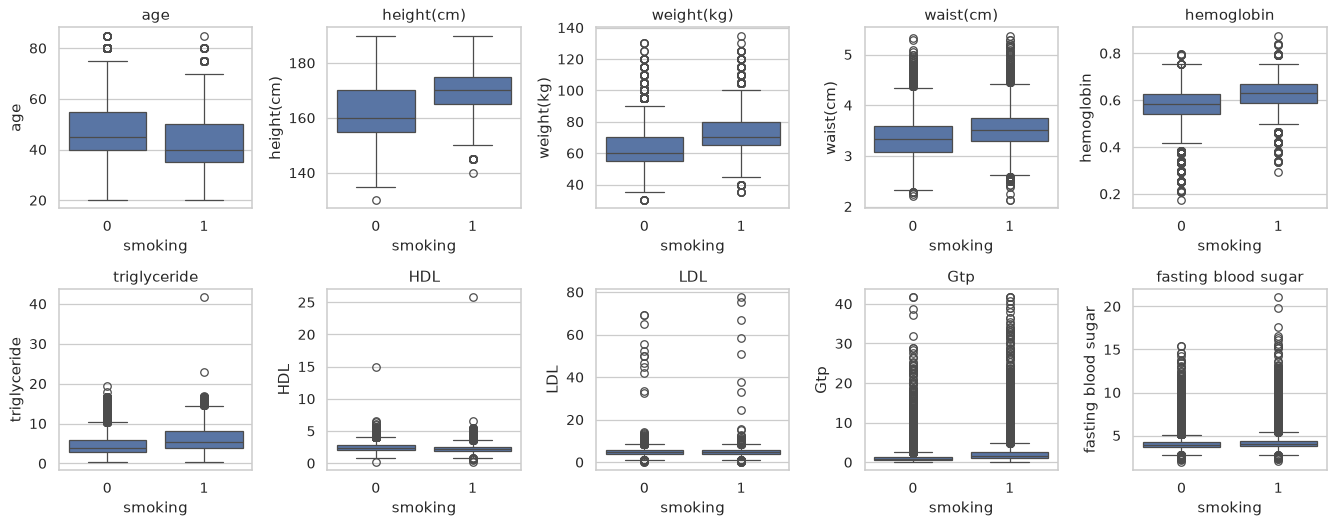

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, col in zip(axes.flat, num_focus):
    sns.boxplot(data=df, x='smoking', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

## Matriz de correlacion (numericas)

Como `smoking` es binaria, la correlacion lineal con el target es un indicador **limitado**: la lectura mas confiable de "importancia" la vamos a sacar del modelo entrenado (notebook 05). Aun asi sirve para ver redundancia entre features numericas.

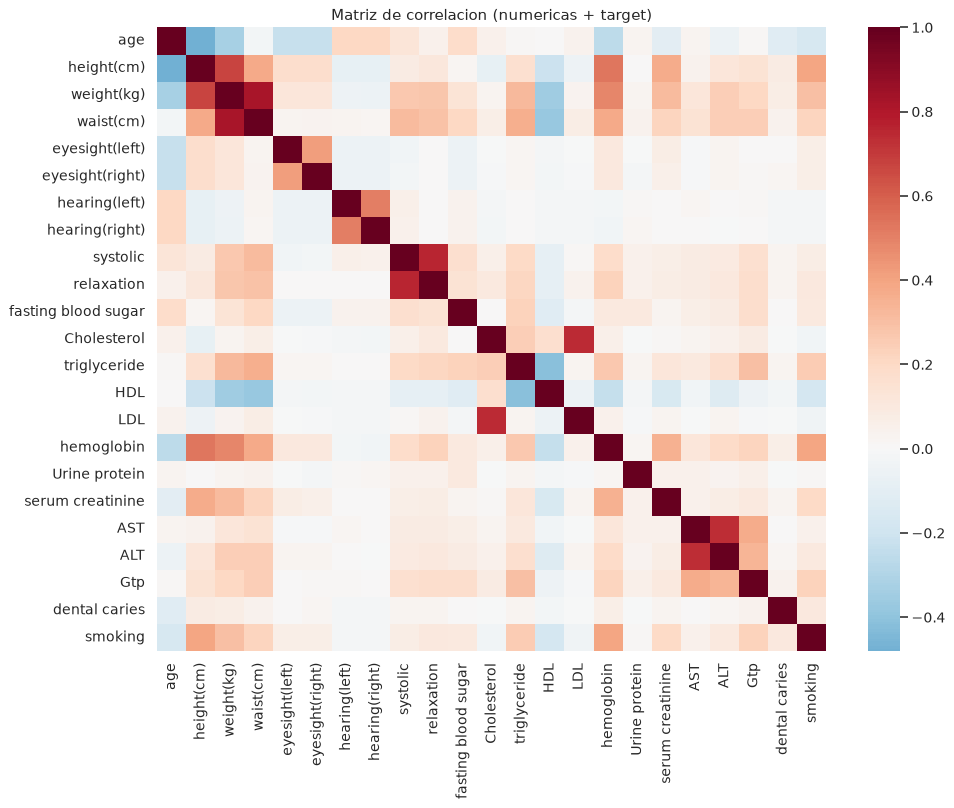

In [7]:
num_cols = df.select_dtypes(include='number').columns.drop(['ID', 'smoking'])
corr = df[num_cols.tolist() + ['smoking']].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax)
ax.set_title('Matriz de correlacion (numericas + target)')
plt.show()

### Top correlaciones lineales con `smoking`

In [8]:
corr_target = corr['smoking'].drop('smoking').sort_values(key=lambda s: s.abs(), ascending=False)
corr_target.head(10)

height(cm)          0.396284
hemoglobin          0.395972
weight(kg)          0.301405
triglyceride        0.251116
Gtp                 0.235980
waist(cm)           0.224623
serum creatinine    0.198660
HDL                -0.176993
age                -0.163722
relaxation          0.108155
Name: smoking, dtype: float64

## Outliers (resumen)

Hay valores extremos en `triglyceride`, `Gtp`, `ALT`, `AST`. Decision: **no se imputan ni recortan** outliers porque (a) son valores fisiologicamente posibles, (b) cualquier regla aplicada aca tendria que reproducirse identica en prediccion sobre datos nuevos y eso suma complejidad sin un upside claro. Los modelos basados en arboles (RF, XGBoost) son robustos a outliers.

In [9]:
df[num_focus].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)

,mean,std,min,50%,max
age,44.19,12.09,20.00,40.00,85.00
height(cm),164.65,9.21,130.00,165.00,190.00
weight(kg),65.88,12.83,30.00,65.00,135.00
waist(cm),3.41,0.39,2.12,3.42,5.38
hemoglobin,0.59,0.07,0.17,0.59,0.88
triglyceride,5.28,2.98,0.33,4.50,41.62
HDL,2.39,0.62,0.17,2.29,25.75
LDL,4.79,1.71,0.04,4.71,77.50
Gtp,1.67,2.11,0.04,1.04,41.62
fasting blood sugar,4.14,0.87,1.92,4.00,21.04


In [ ]:
# gender parece ser la más importante, lo vamos a confirmar con feature importance
df.groupby('gender')['smoking'].mean().round(3)